# Seq2Seq

Seq2Seq（Sequence-to-Sequence）是一種把一段序列轉換成另一段序列的模型。

可以把它想成：

* 輸入：一串東西（文字、數字、符號）
* 輸出：另一串東西（通常長度不一定一樣）

> 核心概念只有一句話：「先讀完整段輸入 → 再一個一個生成輸出」

<img src="image/Seq2seq_ani.gif" alt="seq2seq" style="width: 70%;"/>

---

## 基本架構（Encoder–Decoder）

Seq2Seq 主要由兩個部分組成：

### 1️⃣ Encoder（編碼器）

負責把輸入序列壓縮成一個「語意向量」。

假設輸入為：

$$
x_1, x_2, ..., x_T
$$

經過 RNN / LSTM / GRU：

$$
h_t = f(x_t, h_{t-1})
$$

最後得到：

$$
c = h_T
$$

這個 $c$ 就是整句話的「摘要」。

---

### 2️⃣ Decoder（解碼器）

負責把語意向量轉換成輸出序列。

初始化：

$$
h_0^{dec} = c
$$

接著逐步生成：

$$
h_t^{dec} = f(y_{t-1}, h_{t-1}^{dec})
$$

$$
p_t = \text{softmax}(W h_t^{dec})
$$

$$
\hat{y}_t = \arg\max p_t
$$

---

## 一個直覺範例（機器翻譯）

輸入（英文）：I love you

Encoder 會變成：→ [語意向量 c]

Decoder 再生成（中文）：我 → 愛 → 你


---

## 訓練方式（Teacher Forcing）

訓練時，Decoder 的輸入不是自己的預測，而是「正確答案」：

$$
x_t^{dec} = y_{t-1}^{(ground\ truth)}
$$

這樣可以：

- 減少誤差累積
- 加快收斂
- 提升穩定性

---

## 推論（Inference）

實際使用時：

$$
x_t^{dec} = \hat{y}_{t-1}
$$

也就是：

「用自己剛剛生成的結果，當作下一步的輸入」

---

## 數學整體流程整理

### Encoder

$$
h_t = f(x_t, h_{t-1})
$$

$$
c = h_T
$$

---

### Decoder

$$
h_t^{dec} = f(y_{t-1}, h_{t-1}^{dec})
$$

$$
p_t = \text{softmax}(W h_t^{dec})
$$

---

### Loss（Cross Entropy）

$$
L = - \sum_{t} \log p(y_t)
$$

---

## 重要限制（為什麼會有 Attention）

Seq2Seq 的瓶頸在於：整句話 → 壓成一個向量 c


問題：

- 長句資訊容易遺失
- Encoder 的資訊被「擠壓」

👉 這就是為什麼後來會出現：

**Attention 機制（讓 Decoder 可以回頭看每個時間點）**

---

## 一句話總結

Seq2Seq 本質就是：

> 用一個模型把「整段輸入壓縮」→ 再用另一個模型「一步一步生成輸出」

In [8]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

## 特殊 token 與工具函式

In [9]:
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"


def softmax(x):
    # 做 numerical stability，避免 exp 爆掉
    z = x - np.max(x)
    e = np.exp(z)
    return e / np.sum(e)


def cross_entropy_and_grad(logits, target_idx):
    """
    給定一個 timestep 的 logits 與正確類別 target_idx，
    回傳：
    - cross entropy loss
    - 對 logits 的梯度 dL/dlogits
    """
    probs = softmax(logits)
    loss = -np.log(probs[target_idx] + 1e-12)

    grad = probs.copy()
    grad[target_idx] -= 1.0
    return loss, grad

## 建立字元詞彙表（character vocabulary）

這裡採用 **character-level translation**：

- 輸入：例如 `"i am cold"`
- 輸出：例如 `"j ai froid"`

優點是實作最直觀，也方便手刻 one-hot 與 BPTT。

In [10]:
class CharVocab:
    def __init__(self, texts):
        # 將所有文字串接後取出不重複字元，並排序以固定索引順序
        chars = sorted(set("".join(texts)))

        # 先建立特殊 token 的索引
        self.char2idx = {
            SOS_TOKEN: 0,
            EOS_TOKEN: 1,
        }

        # 一般字元從 index 2 開始編號
        next_idx = 2
        for ch in chars:
            if ch not in self.char2idx:
                self.char2idx[ch] = next_idx
                next_idx += 1

        # 建立反向查表：index -> 字元
        self.idx2char = {idx: ch for ch, idx in self.char2idx.items()}

        # 快速存取常用特殊 token id
        self.sos_id = self.char2idx[SOS_TOKEN]
        self.eos_id = self.char2idx[EOS_TOKEN]

        # vocabulary 總大小
        self.size = len(self.char2idx)

    def encode(self, text, add_eos=True):
        # 將文字逐字轉成對應的 index
        ids = [self.char2idx[ch] for ch in text]

        # 視需求在句尾補上 <eos>
        if add_eos:
            ids.append(self.eos_id)

        # 回傳整數型別的 numpy 陣列
        return np.array(ids, dtype=np.int64)

    def decode(self, ids, stop_at_eos=True):
        # 將 index 序列還原成文字
        chars = []

        for idx in ids:
            idx = int(idx)

            # 若設定遇到 <eos> 就停止，代表序列到此結束
            if stop_at_eos and idx == self.eos_id:
                break

            # <sos> 只作為起始符號，不輸出到結果文字中
            if idx == self.sos_id:
                continue

            # 將一般 index 轉回對應字元
            chars.append(self.idx2char[idx])

        # 將字元串接回字串
        return "".join(chars)

## 建立一個小型英語與法語翻譯資料集

這是玩具資料集，但足夠讓模型真正學到 mapping。  
Notebook 的重點是 **看清楚 Seq2Seq 的訓練與 backward**，不是追求大型資料表現。

In [11]:
pairs = [
    ("i am cold", "j ai froid"),
    ("i am warm", "j ai chaud"),
    ("i am happy", "je suis heureux"),
    ("i am sad", "je suis triste"),
    ("he is tall", "il est grand"),
    ("he is short", "il est petit"),
    ("she is kind", "elle est gentille"),
    ("she is ready", "elle est prete"),
    ("you are nice", "tu es gentil"),
    ("you are late", "tu es en retard"),
    ("we are ready", "nous sommes prets"),
    ("we are tired", "nous sommes fatigues"),
    ("they are here", "ils sont ici"),
    ("they are busy", "ils sont occupes"),
    ("hello", "bonjour"),
    ("good night", "bonne nuit"),
    ("thank you", "merci"),
    ("see you", "a bientot"),
    ("i love you", "je t aime"),
    ("how are you", "comment ca va"),
]

# pairs = []

# with open("data/fra.txt", "r", encoding="utf-8") as f:
#     for line in f:
#         line = line.strip()
#         if not line:
#             continue
        
#         parts = line.split("\t")
#         if len(parts) >= 2:
#             eng = parts[0].strip().lower()
#             fra = parts[1].strip().lower()
#             pairs.append((eng, fra))


src_vocab = CharVocab([src for src, _ in pairs])
tgt_vocab = CharVocab([tgt for _, tgt in pairs])

dataset = [(src_vocab.encode(src), tgt_vocab.encode(tgt)) for src, tgt in pairs]

print("Number of pairs:", len(dataset))
print("Source vocab size:", src_vocab.size)
print("Target vocab size:", tgt_vocab.size)
print("Example pair:")
print("  src:", pairs[0][0], "->", dataset[0][0])
print("  tgt:", pairs[0][1], "->", dataset[0][1])

Number of pairs: 20
Source vocab size: 24
Target vocab size: 24
Example pair:
  src: i am cold -> [10  2  3 13  2  5 15 12  6  1]
  tgt: j ai froid -> [12  2  3 11  2  8 18 16 11  6  1]


## NumPy Seq2Seq 實作（vanilla RNN 版本）

模型結構：

- **Encoder**：讀完整個 source sequence，得到最後 hidden state
- **Decoder**：從 encoder 最後 hidden state 開始，逐步產生 target sequence
- **Training**：使用 teacher forcing
- **Loss**：每個 decoder timestep 做 cross entropy
- **Backward**：
  1. 先對 decoder 做 BPTT
  2. 把 decoder 初始 hidden 的梯度傳回 encoder 最後 hidden
  3. 再對 encoder 做 BPTT

這正是 Seq2Seq 的核心梯度流。

In [ ]:
class Seq2SeqNumpy:
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_size=64, seed=42):
        rng = np.random.default_rng(seed)

        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        self.hidden_size = hidden_size

        # 用比較小的初始化，避免一開始 tanh 飽和
        scale = 0.08

        # Encoder 參數
        self.Wxh_enc = rng.normal(0, scale, (hidden_size, src_vocab_size))
        self.Whh_enc = rng.normal(0, scale, (hidden_size, hidden_size))
        self.bh_enc = np.zeros(hidden_size)

        # Decoder 參數
        self.Wxh_dec = rng.normal(0, scale, (hidden_size, tgt_vocab_size))
        self.Whh_dec = rng.normal(0, scale, (hidden_size, hidden_size))
        self.bh_dec = np.zeros(hidden_size)

        # Decoder output layer
        self.Who = rng.normal(0, scale, (tgt_vocab_size, hidden_size))
        self.bo = np.zeros(tgt_vocab_size)

    # -----------------------------
    # Utility
    # -----------------------------
    def one_hot(self, idx, size):
        x = np.zeros(size)
        x[int(idx)] = 1.0
        return x

    def zero_grads(self):
        self.dWxh_enc = np.zeros_like(self.Wxh_enc)
        self.dWhh_enc = np.zeros_like(self.Whh_enc)
        self.dbh_enc = np.zeros_like(self.bh_enc)

        self.dWxh_dec = np.zeros_like(self.Wxh_dec)
        self.dWhh_dec = np.zeros_like(self.Whh_dec)
        self.dbh_dec = np.zeros_like(self.bh_dec)

        self.dWho = np.zeros_like(self.Who)
        self.dbo = np.zeros_like(self.bo)

    # -----------------------------
    # Forward
    # -----------------------------
    def forward(self, src_ids, tgt_ids, teacher_forcing=True):
        """
        src_ids: source token ids, shape (T_src,)
        tgt_ids: target token ids, shape (T_tgt,)

        回傳：
        - average loss
        - cache（供 backward 使用）
        """

        # ===== Encoder forward =====
        enc_xs = []
        enc_hs = []

        h = np.zeros(self.hidden_size)

        for token in src_ids:
            x = self.one_hot(token, self.src_vocab_size)
            h_prev = h
            h = np.tanh(self.Wxh_enc @ x + self.Whh_enc @ h_prev + self.bh_enc)

            enc_xs.append(x)
            enc_hs.append(h)

        enc_last = h.copy()

        # ===== Decoder forward =====
        dec_xs = []
        dec_hs = []
        logits_list = []

        loss = 0.0

        decoder_input = 0  # <sos>
        h = enc_last.copy()

        for target in tgt_ids:
            x = self.one_hot(decoder_input, self.tgt_vocab_size)
            h_prev = h
            h = np.tanh(self.Wxh_dec @ x + self.Whh_dec @ h_prev + self.bh_dec)
            logits = self.Who @ h + self.bo

            step_loss, _ = cross_entropy_and_grad(logits, int(target))
            loss += step_loss

            dec_xs.append(x)
            dec_hs.append(h)
            logits_list.append(logits)

            if teacher_forcing:
                decoder_input = int(target)
            else:
                decoder_input = int(np.argmax(logits))

        avg_loss = loss / len(tgt_ids)

        cache = {
            "src_ids": src_ids,
            "tgt_ids": tgt_ids,
            "enc_xs": enc_xs,
            "enc_hs": enc_hs,
            "enc_last": enc_last,
            "dec_xs": dec_xs,
            "dec_hs": dec_hs,
            "logits_list": logits_list,
        }

        return avg_loss, cache

    # -----------------------------
    # Backward
    # -----------------------------
    def backward(self, cache):
        """
        這裡手刻完整的 BPTT：

        1. decoder output layer backward
        2. decoder RNN backward through time
        3. 把 decoder t=0 前的 hidden 梯度傳回 encoder 最後 hidden
        4. encoder backward through time
        """
        self.zero_grads()

        src_ids = cache["src_ids"]
        tgt_ids = cache["tgt_ids"]

        enc_xs = cache["enc_xs"]
        enc_hs = cache["enc_hs"]
        enc_last = cache["enc_last"]

        dec_xs = cache["dec_xs"]
        dec_hs = cache["dec_hs"]
        logits_list = cache["logits_list"]

        # ===== Decoder backward =====
        T_dec = len(tgt_ids)
        dh_next = np.zeros(self.hidden_size)

        for t in reversed(range(T_dec)):
            h = dec_hs[t]
            h_prev = enc_last if t == 0 else dec_hs[t - 1]
            x = dec_xs[t]

            # dL/dlogits
            _, dlogits = cross_entropy_and_grad(logits_list[t], int(tgt_ids[t]))
            dlogits /= T_dec  # 因為 forward 使用 average loss

            # output layer 梯度
            self.dWho += np.outer(dlogits, h)
            self.dbo += dlogits

            # 從 output layer 回到 hidden
            dh = self.Who.T @ dlogits + dh_next

            # tanh backward
            da = (1.0 - h * h) * dh

            self.dbh_dec += da
            self.dWxh_dec += np.outer(da, x)
            self.dWhh_dec += np.outer(da, h_prev)

            dh_next = self.Whh_dec.T @ da

        # decoder 最開始的 hidden，就是 encoder 最後 hidden
        d_enc_last = dh_next.copy()

        # ===== Encoder backward =====
        T_enc = len(src_ids)
        dh_next = d_enc_last

        for t in reversed(range(T_enc)):
            h = enc_hs[t]
            h_prev = np.zeros(self.hidden_size) if t == 0 else enc_hs[t - 1]
            x = enc_xs[t]

            da = (1.0 - h * h) * dh_next

            self.dbh_enc += da
            self.dWxh_enc += np.outer(da, x)
            self.dWhh_enc += np.outer(da, h_prev)

            dh_next = self.Whh_enc.T @ da

    # -----------------------------
    # Optimizer helpers
    # -----------------------------
    def clip_grads(self, max_norm=1.0):
        total_norm_sq = 0.0
        for grad in [
            self.dWxh_enc,
            self.dWhh_enc,
            self.dbh_enc,
            self.dWxh_dec,
            self.dWhh_dec,
            self.dbh_dec,
            self.dWho,
            self.dbo,
        ]:
            total_norm_sq += np.sum(grad**2)

        total_norm = np.sqrt(total_norm_sq)

        if total_norm > max_norm:
            scale = max_norm / (total_norm + 1e-8)

            self.dWxh_enc *= scale
            self.dWhh_enc *= scale
            self.dbh_enc *= scale

            self.dWxh_dec *= scale
            self.dWhh_dec *= scale
            self.dbh_dec *= scale

            self.dWho *= scale
            self.dbo *= scale

        return total_norm

    def step(self, lr=0.1):
        self.Wxh_enc -= lr * self.dWxh_enc
        self.Whh_enc -= lr * self.dWhh_enc
        self.bh_enc -= lr * self.dbh_enc

        self.Wxh_dec -= lr * self.dWxh_dec
        self.Whh_dec -= lr * self.dWhh_dec
        self.bh_dec -= lr * self.dbh_dec

        self.Who -= lr * self.dWho
        self.bo -= lr * self.dbo

    # -----------------------------
    # Inference
    # -----------------------------
    def translate_ids(self, src_ids, max_len=80):
        # encoder
        h = np.zeros(self.hidden_size)
        for token in src_ids:
            x = self.one_hot(token, self.src_vocab_size)
            h = np.tanh(self.Wxh_enc @ x + self.Whh_enc @ h + self.bh_enc)

        # decoder
        decoder_input = 0  # <sos>
        outputs = []

        for _ in range(max_len):
            x = self.one_hot(decoder_input, self.tgt_vocab_size)
            h = np.tanh(self.Wxh_dec @ x + self.Whh_dec @ h + self.bh_dec)
            logits = self.Who @ h + self.bo

            pred = int(np.argmax(logits))
            outputs.append(pred)

            if pred == 1:  # <eos>
                break

            decoder_input = pred

        return outputs

    def translate_text(self, text, src_vocab, tgt_vocab, max_len=80):
        src_ids = src_vocab.encode(text)
        pred_ids = self.translate_ids(src_ids, max_len=max_len)
        return tgt_vocab.decode(pred_ids)

## 訓練函式

這裡採用最簡單的 SGD：

- 每次拿一筆 pair
- 做 forward
- 做 backward
- gradient clipping
- 更新參數

由於資料很小，這種寫法足夠直觀。

In [13]:
def train_model(
    model,
    dataset,
    epochs=400,
    lr=0.1,
    teacher_forcing=True,
    grad_clip=1.0,
    print_every=50,
):
    losses = []

    for epoch in range(1, epochs + 1):
        random.shuffle(dataset)
        total_loss = 0.0

        for src_ids, tgt_ids in dataset:
            loss, cache = model.forward(
                src_ids=src_ids,
                tgt_ids=tgt_ids,
                teacher_forcing=teacher_forcing,
            )
            model.backward(cache)
            model.clip_grads(grad_clip)
            model.step(lr=lr)

            total_loss += loss

        avg_loss = total_loss / len(dataset)
        losses.append(avg_loss)

        if epoch % print_every == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | avg_loss = {avg_loss:.4f}")

    return losses

## 開始訓練

In [14]:
model = Seq2SeqNumpy(
    src_vocab_size=src_vocab.size,
    tgt_vocab_size=tgt_vocab.size,
    hidden_size=64,
    seed=42,
)

losses = train_model(
    model=model,
    dataset=dataset,
    epochs=600,
    lr=0.1,
    teacher_forcing=True,
    grad_clip=1.0,
    print_every=50,
)

Epoch    1 | avg_loss = 3.1281
Epoch   50 | avg_loss = 1.0462
Epoch  100 | avg_loss = 0.1985
Epoch  150 | avg_loss = 0.0417
Epoch  200 | avg_loss = 0.0114
Epoch  250 | avg_loss = 0.0086
Epoch  300 | avg_loss = 0.0051
Epoch  350 | avg_loss = 0.0040
Epoch  400 | avg_loss = 0.0032
Epoch  450 | avg_loss = 0.0311
Epoch  500 | avg_loss = 0.0024
Epoch  550 | avg_loss = 0.0021
Epoch  600 | avg_loss = 0.0019


## 觀察 loss

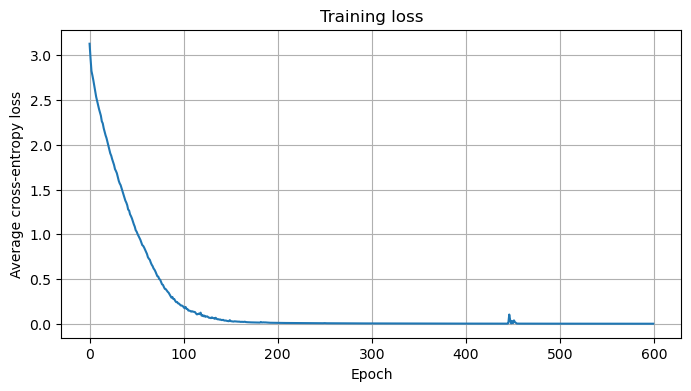

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.grid(True)
plt.show()

## 看訓練集翻譯結果

In [16]:
for src_text, tgt_text in pairs:
    pred_text = model.translate_text(src_text, src_vocab, tgt_vocab)
    print(f"SRC : {src_text}")
    print(f"TGT : {tgt_text}")
    print(f"PRED: {pred_text}")
    print("-" * 50)

SRC : i am cold
TGT : j ai froid
PRED: j ai froid
--------------------------------------------------
SRC : i am warm
TGT : j ai chaud
PRED: j ai chaud
--------------------------------------------------
SRC : i am happy
TGT : je suis heureux
PRED: je suis heureux
--------------------------------------------------
SRC : i am sad
TGT : je suis triste
PRED: je suis triste
--------------------------------------------------
SRC : he is tall
TGT : il est grand
PRED: il est grand
--------------------------------------------------
SRC : he is short
TGT : il est petit
PRED: il est petit
--------------------------------------------------
SRC : she is kind
TGT : elle est gentille
PRED: elle est gentille
--------------------------------------------------
SRC : she is ready
TGT : elle est prete
PRED: elle est prete
--------------------------------------------------
SRC : you are nice
TGT : tu es gentil
PRED: tu es gentil
--------------------------------------------------
SRC : you are late
TGT : tu 

## 測幾個輸入

這是很小的訓練集，所以模型主要是在 **memorize + generalize 一點點字元模式**。  
如果你要更像真正翻譯模型，需要：

- 更大的資料集
- word/subword tokenization
- embedding
- attention
- GRU / LSTM / Transformer

In [17]:
tests = [
    "i am cold",
    "i am warm",
    "he is tall",
    "thank you",
    "good night",
]

for text in tests:
    pred = model.translate_text(text, src_vocab, tgt_vocab)
    print(f"{text:>12s}  ->  {pred}")

   i am cold  ->  j ai froid
   i am warm  ->  j ai chaud
  he is tall  ->  il est grand
   thank you  ->  merci
  good night  ->  bonne nuit


## 這份 Notebook 與原始版本的對照理解

你原始檔案的意圖大致是：

- Encoder 讀 source
- Decoder 用 teacher forcing 讀 target
- 計算 loss
- 從 decoder backward 回 encoder

這份 Notebook 完整保留這個核心結構，只是做了幾個必要調整：

### 1. 拿掉外部依賴
原始程式依賴未提供的 `GRU`, `Dense`, `util`, `SGD`。  
這裡全部改成 Notebook 內自含實作，方便逐格理解與除錯。

### 2. 明確快取 cache
原始版本把很多中間變數掛在 `self.xxx` 上，追蹤不易。  
這裡統一用 `cache` 保存 forward 所需資訊，backward 可直接對照。

### 3. 梯度路徑明確
原始版本中 `decoder.backward()` 回傳的 `dhidden` 再丟給 encoder，shape 比較隱含。  
這裡明寫成：

- decoder BPTT
- `d_enc_last = dh_next`
- encoder BPTT

更容易驗證數學正確性。

### 4. 避免 validation 時修改不自然的 ratio
原始版本把 `teacher_forcing_ratio = 1.1` 當成「一定使用 teacher forcing」。  
這裡直接用布林 `teacher_forcing=True/False`，語意比較乾淨。

### 5. 統一 loss 標準
這裡每個樣本的 loss 都明確做 `平均到 target 長度`，因此 backward 也同步把 `dlogits /= T_dec`。

## 你接下來最值得做的升級

如果你想把它進一步拉近原始目標，最合理的順序是：

1. **把 recurrent cell 從 vanilla RNN 換成 GRU**
2. **加入 attention**
3. **加入 mini-batch**
4. **改用 embedding，取代 one-hot**
5. **把資料換成真實的 bilingual corpus**

如果你要，我下一步可以直接幫你做其中一個版本：

- **A. NumPy GRU Seq2Seq Notebook**
- **B. NumPy Attention Seq2Seq Notebook**
- **C. PyTorch 對照版 Notebook**